In [1]:
import json
from typing import TypedDict, List, Literal, Annotated, Sequence, Optional, Dict, Any
from uuid import uuid4
from langchain_core.messages import BaseMessage, SystemMessage, AIMessage, HumanMessage
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, END
from langgraph.types import Command
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
from pydantic import BaseModel, Field
from langgraph.checkpoint.memory import MemorySaver

In [2]:
#for dev in mem later persistent db
checkpointer = MemorySaver()

In [3]:
load_dotenv()


True

In [4]:
class CriterionAssessment(BaseModel):
    completed:bool = Field(description="Weather this criterion is satisfied")
    confidence:float = Field(ge=0.0, le=1.0, description="Confidence for this criterion")
    reason:str = Field(description="Short evidence backed rationale")

class DiscussionAssessment(BaseModel):
    approach_explained: CriterionAssessment
    edge_cases_discussed: CriterionAssessment
    complexity_discussed: CriterionAssessment
    next_question: str = Field(min_length=1, description="Interviewer follow-up question for the candidate")
    

class CodingAssessment(BaseModel):
    code_submitted: CriterionAssessment
    walkthrough_provided: CriterionAssessment
    correctness_discussed: CriterionAssessment
    next_question: str = Field(min_length=1, description="Interviewer follow-up question for coding phase")


class ReviewAssessment(BaseModel):
    optimization_discussed: CriterionAssessment
    edge_case_validation: CriterionAssessment
    final_complexity_summary: CriterionAssessment
    next_question: str = Field(min_length=1, description="Interviewer follow-up question for review phase")

In [5]:
class InterviewAgentState(TypedDict):
    session_id: str
    phase: Literal["PROBLEM_DISCUSSION", "CODING", "REVIEW", "FEEDBACK"]
    messages: Annotated[Sequence[BaseMessage], add_messages]
    problem_statement: str
    problem_references: Optional[Dict[str, Any]]

    user_code: Optional[str]
    user_code_output: Optional[Dict[str, Any]]
    execution_attempts: int

    discussion_turns: int
    review_turns: int
    coding_turns: int

    discussion_assessment: Optional[Dict[str, Any]]
    coding_assessment: Optional[Dict[str, Any]]
    review_assessment: Optional[Dict[str, Any]]
    feedback: Optional[Dict[str, Any]]

In [6]:
base_llm = ChatGoogleGenerativeAI(
    model = "gemini-flash-lite-latest",
    # model = "gemini-3.1-flash-lite-preview"
)

In [7]:
BASE_PROMPT = """
You are a senior technical interviewer.
Ask concise, rigorous questions aligned to the current interview phase.
Do not provide complete solutions for the candidate.
"""

In [8]:
def interview_init_node(state: InterviewAgentState) -> dict:
    existing_messages = list(state.get("messages", []))
    # Skip only if this session has already produced interviewer output.
    if any(isinstance(msg, AIMessage) for msg in existing_messages):
        return {"phase": "PROBLEM_DISCUSSION"}

    init_prompt = """
    CURRENT PHASE: INTERVIEW_INITIALIZATION

    Your responsibilities:
    1. Briefly greet the candidate.
    2. Explain that this will be a structured technical interview.
    3. Mention that you will first discuss the approach before writing code.
    4. Clearly present the problem statement.
    5. Ask the candidate to:
        - Propose an initial approach.
    Do NOT:
    - Give hints.
    - Suggest the optimal approach.
    - Ask for full code.
    - Evaluate the candidate.
    - Prolong the interview initialization indefinitely. Move to the next phase quickly if the standard is met.
    End your message with a clear open-ended question to transition to the discussion smoothly.
    """

    problem_statement = state.get("problem_statement") or ""
    problem_references = state.get("problem_references") or ""

    final_prompt = (
        f"{BASE_PROMPT}\n{init_prompt}\n"
        f"{problem_references}\n\n"
        f"Problem Statement:\n{problem_statement}"
    )

    starter_content = "Please start the interview."
    if existing_messages and isinstance(existing_messages[-1], HumanMessage):
        starter_content = str(existing_messages[-1].content or "").strip() or starter_content

    messages = [
        SystemMessage(content=final_prompt),
        HumanMessage(content=starter_content),
    ]

    res = base_llm.invoke(messages)

    print(f"AI message: {res.content}")

    return {
        "phase": "PROBLEM_DISCUSSION",
        "messages": [res]
    }

In [9]:
def problem_discussion_phase_node(state: InterviewAgentState) -> dict:

    prompt = """
    CURRENT PHASE: PROBLEM_DISCUSSION

    Your job:
    1. Analyze candidate's latest response
    2. Determine if they have reasonably addressed:
       - Approach
       - Edge cases
       - Time & space complexity
    3. Ask a follow-up question ONLY if a major component is missing or completely wrong.

    Rules:
    - Do NOT ask for code
    - Do NOT give hints
    - Be concise and interviewer-like
    - Do NOT ask unnecessary or incredibly minute follow-up questions once the main goal of the phase is achieved.
    - Do not prolong the interview indefinitely. Move to the next phase quickly if the standard is met.
    - Set completion flags to True and ensure confidence is high (>= 0.7) for reasonable answers.
    - Once approach, edge cases, and complexity are reasonably addressed, tell the candidate to start coding. Set all completion flags to True.

    Output MUST follow DiscussionAssessment schema.
    """

    messages = state.get("messages", [])

    if not messages or not isinstance(messages[-1], HumanMessage):
        return {}

    problem_statement = state.get("problem_statement") or ""
    problem_references = state.get("problem_references") or {}
    phase_prompt = (
        f"{prompt}\n\n"
        f"Problem References: {problem_references}\n"
        f"Problem Statement: {problem_statement}"
    )

    # LLM call with structured output
    res: DiscussionAssessment = base_llm.with_structured_output(
        DiscussionAssessment
    ).invoke([
        SystemMessage(content=phase_prompt),
        *messages[-6:],  # windowing (important)
    ])

    previous_assessment = state.get("discussion_assessment") or {}

    def _merge_criterion(prev: Any, curr: CriterionAssessment) -> Dict[str, Any]:
        prev_completed = bool((prev or {}).get("completed", False)) if isinstance(prev, dict) else False
        prev_confidence = float((prev or {}).get("confidence", 0.0)) if isinstance(prev, dict) else 0.0
        prev_reason = (prev or {}).get("reason", "") if isinstance(prev, dict) else ""

        merged_completed = prev_completed or curr.completed
        merged_confidence = max(prev_confidence, curr.confidence)
        merged_reason = curr.reason if curr.reason else prev_reason

        return {
            "completed": merged_completed,
            "confidence": merged_confidence,
            "reason": merged_reason,
        }

    updated_assessment = {
        "approach_explained": _merge_criterion(
            previous_assessment.get("approach_explained"),
            res.approach_explained,
        ),
        "edge_cases_discussed": _merge_criterion(
            previous_assessment.get("edge_cases_discussed"),
            res.edge_cases_discussed,
        ),
        "complexity_discussed": _merge_criterion(
            previous_assessment.get("complexity_discussed"),
            res.complexity_discussed,
        ),
    }

    assistant_message = AIMessage(content=res.next_question)

    return {
        "phase": "PROBLEM_DISCUSSION",
        "messages": [assistant_message],
        "discussion_turns": state.get("discussion_turns", 0) + 1,
        "discussion_assessment": updated_assessment,
    }

In [10]:
def discussion_router(state: InterviewAgentState):
    discussion_phase_flags = state.get("discussion_assessment") or {}
    if not isinstance(discussion_phase_flags, dict):
        return "PROBLEM_DISCUSSION"

    approach_flags = discussion_phase_flags.get("approach_explained") or {}
    edge_case_flags = discussion_phase_flags.get("edge_cases_discussed") or {}
    complexity_flags = discussion_phase_flags.get("complexity_discussed") or {}

    def _is_complete(flag: Dict[str, Any]) -> bool:
        return bool(flag.get("completed")) and float(flag.get("confidence", 0.0)) >= 0.7

    if (
        _is_complete(approach_flags) and
        _is_complete(edge_case_flags) and
        _is_complete(complexity_flags)
    ):
        return "CODING"

    return "PROBLEM_DISCUSSION"

In [11]:
def coding_phase_node(state: InterviewAgentState) -> dict:

    prompt = """
    CURRENT PHASE: CODING

    Your job:
    1. Check if candidate has submitted code
    2. Check if candidate provided a walkthrough
    3. Check whether correctness has been genuinely discussed
    4. Ask a follow-up question ONLY if major parts are missing or fundamentally flawed.

    Rules:
    - DO NOT give full solution
    - DO NOT rewrite full code
    - Give hints only if needed
    - Be concise
    - Do NOT ask unnecessary or incredibly minute follow-up questions once the code is reasonably correct and understood.
    - Do not prolong the interview indefinitely. Move to the next phase quickly if the standard is met.
    - Set completion flags to True and ensure confidence is high (>= 0.7) for reasonable answers.
    - Once the code is reasonable, the walkthrough is mostly accurate, and correctness is addressed, tell the candidate to proceed to review/optimizations. Set all completion flags to True.

    Output MUST follow CodingAssessment schema.
    """

    messages = state.get("messages", [])

    if not messages or not isinstance(messages[-1], HumanMessage):
        return {}

    problem_statement = state.get("problem_statement") or ""
    problem_references = state.get("problem_references") or {}
    phase_prompt = (
        f"{prompt}\n\n"
        f"Problem References: {problem_references}\n"
        f"Problem Statement: {problem_statement}"
    )

    res: CodingAssessment = base_llm.with_structured_output(
        CodingAssessment
    ).invoke([
        SystemMessage(content=phase_prompt),
        *messages[-6:],   # windowing
    ])

    previous_assessment = state.get("coding_assessment") or {}

    def _merge_criterion(prev: Any, curr: CriterionAssessment) -> Dict[str, Any]:
        prev_completed = bool((prev or {}).get("completed", False)) if isinstance(prev, dict) else False
        prev_confidence = float((prev or {}).get("confidence", 0.0)) if isinstance(prev, dict) else 0.0
        prev_reason = (prev or {}).get("reason", "") if isinstance(prev, dict) else ""

        merged_completed = prev_completed or curr.completed
        merged_confidence = max(prev_confidence, curr.confidence)
        merged_reason = curr.reason if curr.reason else prev_reason

        return {
            "completed": merged_completed,
            "confidence": merged_confidence,
            "reason": merged_reason,
        }

    updated_assessment = {
        "code_submitted": _merge_criterion(
            previous_assessment.get("code_submitted"),
            res.code_submitted,
        ),
        "walkthrough_provided": _merge_criterion(
            previous_assessment.get("walkthrough_provided"),
            res.walkthrough_provided,
        ),
        "correctness_discussed": _merge_criterion(
            previous_assessment.get("correctness_discussed"),
            res.correctness_discussed,
        ),
    }

    assistant_message = AIMessage(content=res.next_question)

    return {
        "phase": "CODING",
        "messages": [assistant_message],
        "coding_turns": state.get("coding_turns", 0) + 1,
        "coding_assessment": updated_assessment,
    }

In [12]:
def coding_router(state: InterviewAgentState):
    coding_phase_flags = state.get("coding_assessment") or {}
    if not isinstance(coding_phase_flags, dict):
        return "CODING"

    code_submitted_flags = coding_phase_flags.get("code_submitted") or {}
    walkthrough_flags = coding_phase_flags.get("walkthrough_provided") or {}
    correctness_flags = coding_phase_flags.get("correctness_discussed") or {}

    def _is_complete(flag: Dict[str, Any]) -> bool:
        return bool(flag.get("completed")) and float(flag.get("confidence", 0.0)) >= 0.7

    if (
        _is_complete(code_submitted_flags) and
        _is_complete(walkthrough_flags) and
        _is_complete(correctness_flags)
    ):
        return "REVIEW"

    return "CODING"

In [13]:
def review_phase_node(state: InterviewAgentState) -> dict:

    prompt = """
    CURRENT PHASE: REVIEW

    Your job:
    1. Check if candidate discussed possible optimizations
    2. Check if candidate validated key edge cases
    3. Check if candidate provided a final complexity summary
    4. Ask a follow-up question ONLY if critical major reviews are skipped.

    Rules:
    - DO NOT give full solution
    - DO NOT rewrite full code
    - Give hints only if needed
    - Be concise
    - Do NOT ask unnecessary or incredibly minute follow-up questions once the main goal of the phase is achieved.
    - Do not prolong the interview indefinitely. Move to the final summary quickly if the standard is met.
    - Set completion flags to True and ensure confidence is high (>= 0.7) for reasonable answers.
    - Once optimizations, edge cases, and final complexity are reasonably addressed, tell the candidate that the interview is concluding. Set all completion flags to True.

    Output MUST follow ReviewAssessment schema.
    """

    messages = state.get("messages", [])

    if not messages or not isinstance(messages[-1], HumanMessage):
        return {}

    problem_statement = state.get("problem_statement") or ""
    problem_references = state.get("problem_references") or {}
    phase_prompt = (
        f"{prompt}\n\n"
        f"Problem References: {problem_references}\n"
        f"Problem Statement: {problem_statement}"
    )

    res: ReviewAssessment = base_llm.with_structured_output(
        ReviewAssessment
    ).invoke([
        SystemMessage(content=phase_prompt),
        *messages[-6:],   # windowing
    ])

    previous_assessment = state.get("review_assessment") or {}

    def _merge_criterion(prev: Any, curr: CriterionAssessment) -> Dict[str, Any]:
        prev_completed = bool((prev or {}).get("completed", False)) if isinstance(prev, dict) else False
        prev_confidence = float((prev or {}).get("confidence", 0.0)) if isinstance(prev, dict) else 0.0
        prev_reason = (prev or {}).get("reason", "") if isinstance(prev, dict) else ""

        merged_completed = prev_completed or curr.completed
        merged_confidence = max(prev_confidence, curr.confidence)
        merged_reason = curr.reason if curr.reason else prev_reason

        return {
            "completed": merged_completed,
            "confidence": merged_confidence,
            "reason": merged_reason,
        }

    updated_assessment = {
        "optimization_discussed": _merge_criterion(
            previous_assessment.get("optimization_discussed"),
            res.optimization_discussed,
        ),
        "edge_case_validation": _merge_criterion(
            previous_assessment.get("edge_case_validation"),
            res.edge_case_validation,
        ),
        "final_complexity_summary": _merge_criterion(
            previous_assessment.get("final_complexity_summary"),
            res.final_complexity_summary,
        ),
    }

    assistant_message = AIMessage(content=res.next_question)

    return {
        "phase": "REVIEW",
        "messages": [assistant_message],
        "review_turns": state.get("review_turns", 0) + 1,
        "review_assessment": updated_assessment,
    }

In [14]:
def review_router(state: InterviewAgentState):
    review_phase_flags = state.get("review_assessment") or {}
    if not isinstance(review_phase_flags, dict):
        return "REVIEW"

    optimization_flags = review_phase_flags.get("optimization_discussed") or {}
    edge_case_validation_flags = review_phase_flags.get("edge_case_validation") or {}
    final_complexity_flags = review_phase_flags.get("final_complexity_summary") or {}

    def _is_complete(flag: Dict[str, Any]) -> bool:
        return bool(flag.get("completed")) and float(flag.get("confidence", 0.0)) >= 0.7

    if (
        _is_complete(optimization_flags) and
        _is_complete(edge_case_validation_flags) and
        _is_complete(final_complexity_flags)
    ):
        return "FEEDBACK"

    return "REVIEW"

In [15]:
class ScoreWithNotes(BaseModel):
    """A score accompanied by evaluator notes."""
    score: int = Field(ge=0, le=10, description="Integer score from 0 to 10")
    notes: str = Field(min_length=1, description="Brief evaluator notes justifying this score")


class ComplexityScore(BaseModel):
    """Complexity analysis score with identified complexities."""
    score: int = Field(ge=0, le=10, description="Integer score from 0 to 10 evaluating complexity understanding")
    time_complexity: str = Field(min_length=1, description="The time complexity, e.g. O(n), O(n log n)")
    space_complexity: str = Field(min_length=1, description="The space complexity, e.g. O(1), O(n)")
    notes: str = Field(min_length=1, description="Notes on complexity analysis")


class Scores(BaseModel):
    """All evaluation scores."""
    problem_solving: ScoreWithNotes
    complexity_analysis: ComplexityScore
    communication: ScoreWithNotes


class StrengthItem(BaseModel):
    """A specific strength demonstrated by the candidate."""
    category: str = Field(min_length=1)
    title: str = Field(min_length=1)
    description: str = Field(min_length=1)
    impact: Literal["high", "medium", "low"]


class WeaknessItem(BaseModel):
    """A specific area where the candidate needs improvement."""
    category: str = Field(min_length=1)
    title: str = Field(min_length=1)
    description: str = Field(min_length=1)
    severity: Literal["high", "medium", "low"]


class ComplexityMetric(BaseModel):
    """Runtime or memory complexity assessment."""
    value: str = Field(min_length=1)
    status: Literal["optimal", "acceptable", "suboptimal"]


class KeyMetrics(BaseModel):
    """Key performance metrics for the candidate's solution."""
    runtime_complexity: ComplexityMetric
    memory_efficiency: ComplexityMetric
    coding_speed_percentile: int = Field(ge=0, le=100)


class Verdict(BaseModel):
    """Final hiring verdict."""
    decision: Literal["Strong Hire", "Hire", "Lean Hire", "Lean No Hire", "No Hire", "Strong No Hire"]
    confidence: float = Field(ge=0.0, le=1.0)
    summary: str = Field(min_length=1)


class SessionSummary(BaseModel):
    """High-level summary of the interview session."""
    overall_score: int = Field(ge=0, le=100)
    performance_label: Literal["Exceptional", "Strong Performance", "Adequate", "Below Expectations", "Poor"]
    difficulty: Literal["Easy", "Medium", "Hard"]
    time_spent_seconds: int = Field(ge=0)


class FeedbackItem(BaseModel):
    """Comprehensive structured feedback."""
    session_summary: SessionSummary
    scores: Scores
    strengths: List[StrengthItem]
    weaknesses: List[WeaknessItem]
    key_metrics: KeyMetrics
    final_verdict: Verdict


class FeedbackResponseFormat(BaseModel):
    """Response schema for FEEDBACK phase."""
    response: str = Field(min_length=1, description="Brief conversational closing summary.")
    feedback: FeedbackItem

In [16]:
def feedback_phase_node(state: InterviewAgentState) -> dict:

    prompt = """
    CURRENT PHASE: FEEDBACK

    Your job:
    1. Synthesize the full interview performance from discussion, coding, and review assessments
    2. Provide a concise closing response for the candidate
    3. Output complete structured feedback strictly following FeedbackResponseFormat
    4. Provide clear, final feedback without prolonging the conversation. Do not ask any more technical questions. Ensure verdicts make logical sense based on the metrics.

    Rules:
    - Be objective and evidence-based
    - Keep the conversational response brief and professional
    - Do not include private chain-of-thought
    - Never ask another follow-up question

    Output MUST follow FeedbackResponseFormat schema.
    """

    messages = state.get("messages", [])
    if not messages:
        return {}

    discussion_assessment = state.get("discussion_assessment") or {}
    coding_assessment = state.get("coding_assessment") or {}
    review_assessment = state.get("review_assessment") or {}

    context_message = HumanMessage(
        content=
        f"Discussion Assessment: {discussion_assessment}\n"
        f"Coding Assessment: {coding_assessment}\n"
        f"Review Assessment: {review_assessment}"
    )

    res = base_llm.with_structured_output(
        FeedbackResponseFormat
    ).invoke([
        SystemMessage(content=prompt),
        *messages[-6:],
        context_message,
    ])

    assistant_message = AIMessage(content=res.response)

    return {
        "messages": [assistant_message],
        "phase": "FEEDBACK",
        "feedback": res.feedback.model_dump(),
    }

In [17]:
def create_interview_graph(checkpointer_obj: MemorySaver):
    workflow = StateGraph(InterviewAgentState)

    workflow.add_node("interview_init_node", interview_init_node)
    workflow.add_node("problem_discussion_phase_node", problem_discussion_phase_node)
    workflow.add_node("coding_phase_node", coding_phase_node)
    workflow.add_node("review_phase_node", review_phase_node)
    workflow.add_node("feedback_phase_node", feedback_phase_node)

    workflow.set_entry_point("interview_init_node")
    workflow.add_edge("interview_init_node", "problem_discussion_phase_node")
    workflow.add_edge("feedback_phase_node", END)

    workflow.add_conditional_edges(
        source="problem_discussion_phase_node",
        path=discussion_router,
        path_map={
            "CODING": "coding_phase_node",
            "PROBLEM_DISCUSSION": "problem_discussion_phase_node",
        },
    )

    workflow.add_conditional_edges(
        source="coding_phase_node",
        path=coding_router,
        path_map={
            "REVIEW": "review_phase_node",
            "CODING": "coding_phase_node",
        },
    )

    workflow.add_conditional_edges(
        source="review_phase_node",
        path=review_router,
        path_map={
            "REVIEW": "review_phase_node",
            "FEEDBACK": "feedback_phase_node"
        },
    )

    return workflow.compile(
        checkpointer=checkpointer_obj,
        interrupt_after=[
            "problem_discussion_phase_node",
            "coding_phase_node",
            "review_phase_node",
            "feedback_phase_node",
        ],
    )

In [18]:
app = create_interview_graph(checkpointer)

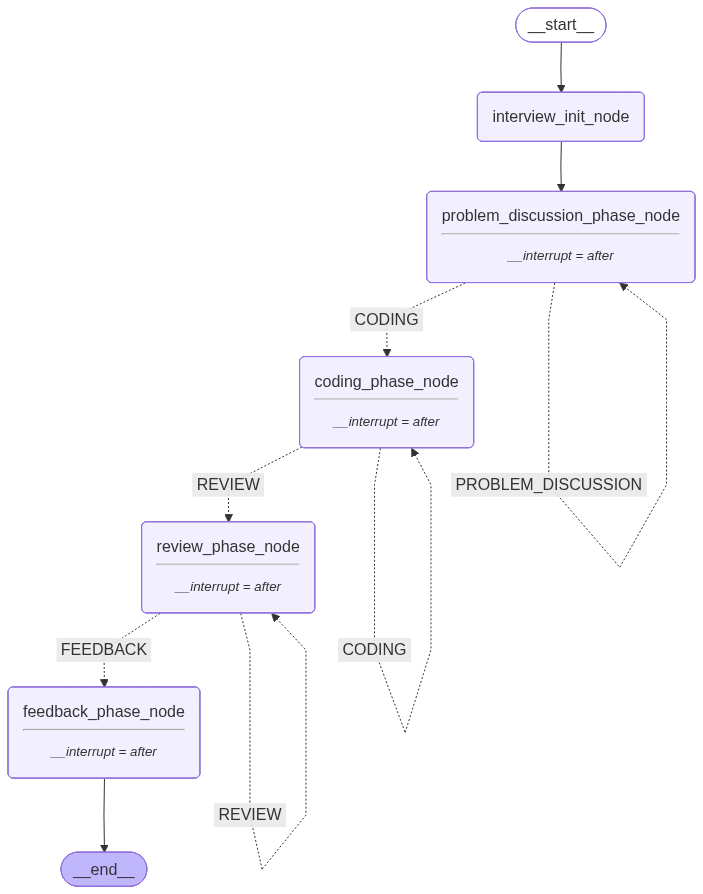

In [19]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
thread_id = f"session_{uuid4().hex[:8]}"
run_config = {"configurable": {"thread_id": thread_id}}

def get_last_ai_message(state):
    messages = state.get("messages", [])
    for msg in reversed(messages):
        if msg.type == "ai":
            return msg.content
    return ""

def run_interview_turn(graph, thread_id, user_input, is_first=False):

    config = {
        "configurable": {
            "thread_id": thread_id
        }
    }

    if is_first:
        state = {
            "session_id": thread_id,
            "phase": "PROBLEM_DISCUSSION",
            "messages": [HumanMessage(content=user_input)],
            "discussion_turns": 0,
            "coding_turns": 0,
            "review_turns": 0,
            "problem_statement": "Given an integer array nums and an integer target, return indices of the two numbers such that they add up to target.",
            "problem_references": {
                "title": "Two Sum",
                "difficulty": "Easy",
                "optimal_approach": "Use a hash map to store seen values and their indices.",
                "time_complexity": "O(n)",
                "space_complexity": "O(n)",
            },
        }
        result = graph.invoke(state, config=config)
    else:
        # 1. Provide the new message to state memory without overriding the timeline
        graph.update_state(config, {"messages": [HumanMessage(content=user_input)]})
        # 2. Invoke with `None` to tell LangGraph to resume from suspended edge
        result = graph.invoke(None, config=config)

    

    return {
        "thread_id": thread_id,
        "response": get_last_ai_message(result),
        "state": result
    }

In [ ]:
def set_user_code(state: InterviewAgentState, code: str) -> dict:
    code_value = (code or "").strip()
    if not code_value:
        return {"user_code": state.get("user_code")}

    return {"user_code": code_value}

In [ ]:
user_input = """



"""
run_interview_turn(app,thread_id,user_input,is_first=False)